# Part 1, Linear Regression: Medical Aid Cost Prediction
**Module:** PDAN8411, Programming for Data Analytics 1
**Client brief:** A South African medical aid scheme wants a proof-of-concept sliding-scale
pricing model, predicting individual medical costs (`charges`) from age, sex, BMI, number of
children, smoking habits and region. A US-based dataset (Kaggle: `mirichoi0218/insurance`) is
used to build and validate the initial model before it is adapted to South African data.

**Dataset:** `insurance.csv`, 1,338 rows, 7 columns (`age`, `sex`, `bmi`, `children`, `smoker`,
`region`, `charges`).


## 1. Suitability of the Dataset for Linear Regression

Linear Regression requires a **continuous numeric target** and predictors that are either
continuous or can be encoded numerically, with a reasonably linear relationship between
predictors and target, independent observations, and no severe multicollinearity.

| Requirement | This dataset |
|---|---|
| Continuous target | `charges` is continuous (USD, positive, right-skewed) |
| Usable predictors | `age`, `bmi`, `children` are numeric; `sex`, `smoker`, `region` are categorical but low-cardinality and easily one-hot/binary encoded |
| Sample size | 1,338 rows, adequate for 6 predictors (well above the rule-of-thumb of ~20 observations per predictor) |
| Missing data | None found |
| Data quality risks | 1 exact duplicate row; `charges` is strongly right-skewed and its variance changes with `smoker` status (heteroscedasticity); `smoker` interacts non-additively with `age`/`bmi`, which a plain linear model under-fits (risk) |
| Multicollinearity | Numeric predictors are largely independent (confirmed with VIF below) |

**Conclusion:** the dataset is suitable for a Linear Regression proof of concept, but its
skewed target and the smoker interaction effect are known pitfalls that must be addressed
(via a log-transform and interaction terms) to get a well-calibrated model: this is planned
for and demonstrated in Section 6 below.


## 2. Analysis Plan

| Step | Plan |
|---|---|
| **a. EDA** | Check shape, dtypes, missing values and duplicates; profile each variable's distribution; visualise `charges` against each predictor (boxplots for categoricals, scatterplots for numerics); build a correlation matrix to spot obvious linear relationships and redundancy. |
| **b. Feature selection** | Encode categoricals (`sex`, `smoker` to binary; `region` to one-hot). Fit a full OLS model in `statsmodels`, inspect coefficient p-values, check VIF for multicollinearity, and use backward elimination (drop the least significant predictor, p > 0.05, one at a time) to reach a parsimonious feature set. |
| **c. Train model** | 80/20 train/test split (`random_state=42` for reproducibility). Baseline model: `sklearn` `LinearRegression` with default (OLS closed-form) hyperparameters, no regularisation needed given the small, low-multicollinearity feature set. |
| **d. Interpret & evaluate** | R-squared, Adjusted R-squared (penalises added predictors), RMSE and MAE (both in Rand-equivalent charge units, business-interpretable), plus residual plots to check the linearity/homoscedasticity assumptions. |
| **e. Report** | Summarise data-cleaning outcomes, EDA insights, modelling approach, and final accuracy in a concise client-facing PDF report (submitted alongside this notebook). |


## 3. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

df = pd.read_csv('insurance.csv')
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 4. Exploratory Data Analysis (EDA)

### 4.1 Structure, data types, missing values and duplicates

In [2]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
df[df.duplicated(keep=False)]


Shape: (1338, 7)

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Exact duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


**Finding:** no missing values. One exact duplicate row is present and will be removed
during data cleaning (Section 5): duplicate records would otherwise bias the model by
double-weighting one observation.

### 4.2 Descriptive statistics

In [3]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


### 4.3 Distribution of the target (`charges`) and key numeric predictors

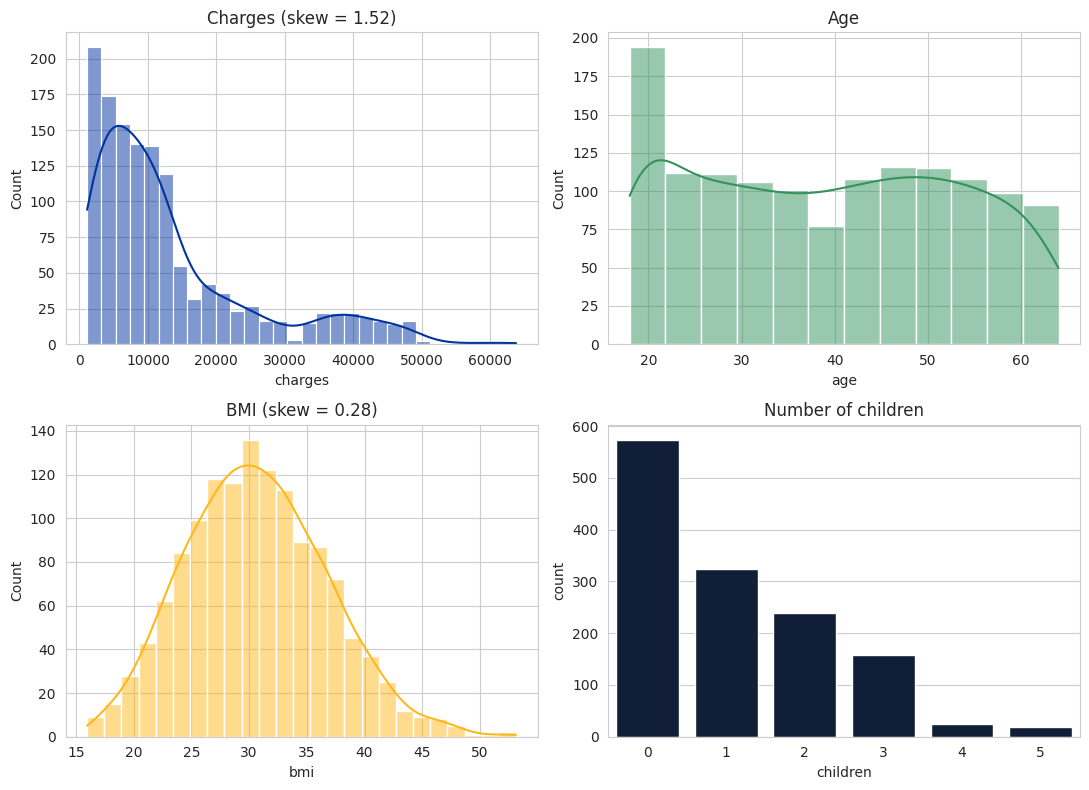

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.histplot(df['charges'], kde=True, ax=axes[0,0], color='#0033A0')
axes[0,0].set_title(f"Charges (skew = {df['charges'].skew():.2f})")
sns.histplot(df['age'], kde=True, ax=axes[0,1], color='#33935C')
axes[0,1].set_title('Age')
sns.histplot(df['bmi'], kde=True, ax=axes[1,0], color='#FFB81C')
axes[1,0].set_title(f"BMI (skew = {df['bmi'].skew():.2f})")
sns.countplot(x='children', data=df, ax=axes[1,1], color='#0A1D3D')
axes[1,1].set_title('Number of children')
plt.tight_layout()
plt.savefig('figures/01_distributions.png', bbox_inches='tight')
plt.show()


**Finding:** `charges` is strongly right-skewed (skew ~ 1.5): most clients incur modest
costs, but a minority (largely smokers) incur very high costs. `bmi` is close to normally
distributed. `age` is roughly uniform across the working-age range. This skew is the reason a
log-transform of `charges` is tested later as a model improvement.

### 4.4 Categorical variables and their relationship with charges

/tmp/ipykernel_2489/1758580796.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0], palette=['#33935C','#FFB81C'])
/tmp/ipykernel_2489/1758580796.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='charges', data=df, ax=axes[1], palette=['#0033A0','#0A1D3D'])
/tmp/ipykernel_2489/1758580796.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='charges', data=df, ax=axes[2], palette='Blues')


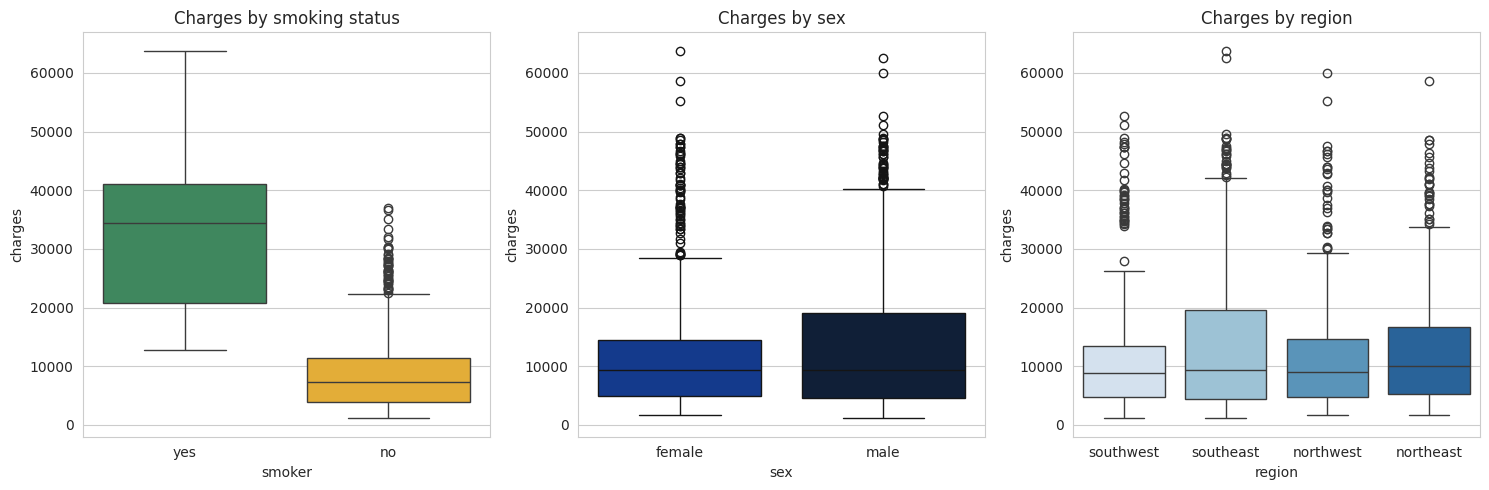

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0], palette=['#33935C','#FFB81C'])
axes[0].set_title('Charges by smoking status')
sns.boxplot(x='sex', y='charges', data=df, ax=axes[1], palette=['#0033A0','#0A1D3D'])
axes[1].set_title('Charges by sex')
sns.boxplot(x='region', y='charges', data=df, ax=axes[2], palette='Blues')
axes[2].set_title('Charges by region')
plt.tight_layout()
plt.savefig('figures/02_categorical_boxplots.png', bbox_inches='tight')
plt.show()


**Finding:** `smoker` status has by far the strongest visible effect on charges: smokers'
median charge is roughly 3-4x that of non-smokers, with almost no overlap between the two
distributions. `sex` shows little visible difference. `region` shows only mild differences,
which is consistent with region acting as a weak/marginal predictor once other factors are
controlled for (confirmed statistically in Section 6).

### 4.5 Numeric predictors vs. charges, split by smoking status

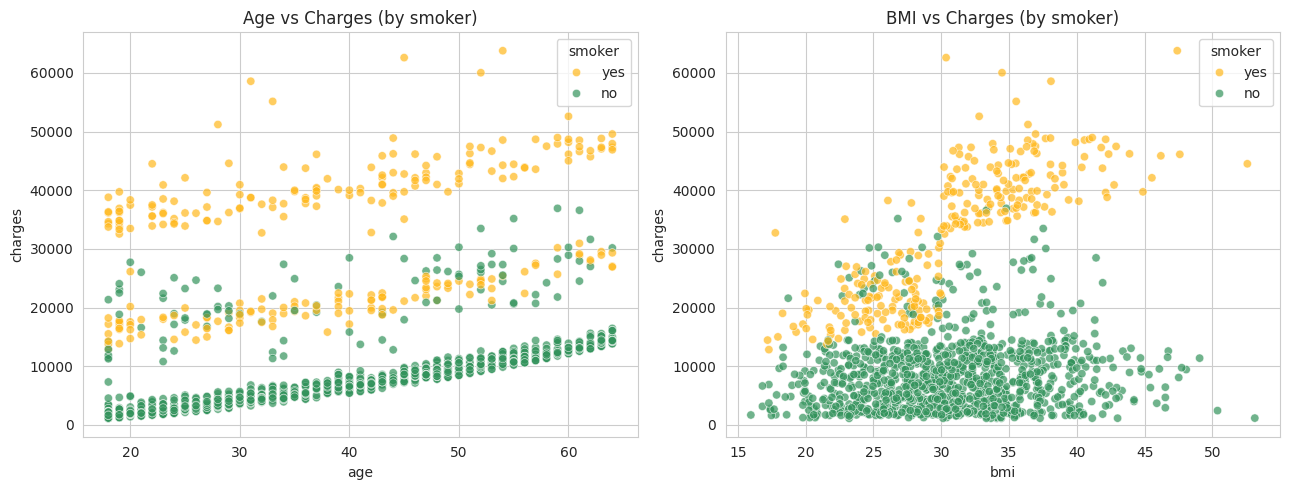

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[0],
                 palette={'yes':'#FFB81C','no':'#33935C'}, alpha=0.7)
axes[0].set_title('Age vs Charges (by smoker)')
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[1],
                 palette={'yes':'#FFB81C','no':'#33935C'}, alpha=0.7)
axes[1].set_title('BMI vs Charges (by smoker)')
plt.tight_layout()
plt.savefig('figures/03_scatter_by_smoker.png', bbox_inches='tight')
plt.show()


**Finding:** age shows three roughly parallel upward bands of charges, with smokers
consistently above non-smokers, showing a fairly linear age effect within each smoker group. BMI's
effect on charges is much steeper for smokers than non-smokers: high-BMI smokers incur sharply
higher charges, while BMI barely moves charges for non-smokers. This is a classic
**interaction effect** (`smoker x bmi`), which a plain additive linear model cannot capture ,
addressed directly in the improved model (Section 8).

### 4.6 Correlation matrix (numeric features + encoded categoricals)

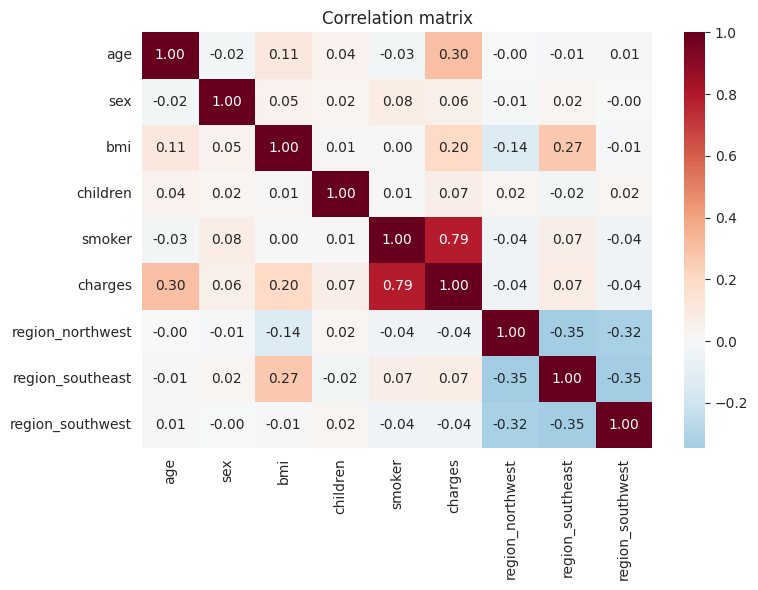

In [7]:
df_corr = df.copy()
df_corr['sex'] = df_corr['sex'].map({'male':1,'female':0})
df_corr['smoker'] = df_corr['smoker'].map({'yes':1,'no':0})
df_corr = pd.get_dummies(df_corr, columns=['region'], drop_first=True)
bool_cols = df_corr.select_dtypes(bool).columns
df_corr[bool_cols] = df_corr[bool_cols].astype(int)

plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('figures/04_correlation_heatmap.png', bbox_inches='tight')
plt.show()


**Finding:** `smoker` correlates most strongly with `charges` (r ~ 0.79), followed by `age`
(r ~ 0.30) and `bmi` (r ~ 0.20). `sex` and `region` correlate very weakly with `charges`.
No pair of predictors is highly correlated with each other, so multicollinearity is not a
concern (confirmed with VIF in Section 6).

## 5. Data Cleaning

Based on the EDA findings above: remove the one exact duplicate row. Outliers in `bmi` and
`charges` are **not** removed: they are legitimate, expected values for an insurance context
(high-BMI, high-cost smokers are precisely the segment the client needs the model to price
correctly), so removing them would bias the model against the group it matters most for.

In [8]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - df.shape[0]} duplicate row(s). New shape: {df.shape}")


Removed 1 duplicate row(s). New shape: (1337, 7)


## 6. Feature Selection

Categorical variables are encoded (`sex`, `smoker` to binary 0/1; `region` to one-hot, dropping
one level to avoid the dummy-variable trap). A full OLS model is fitted in `statsmodels` to
inspect each predictor's p-value, and VIF is checked for multicollinearity. Backward
elimination then removes the least significant predictor.

In [9]:
df_enc = df.copy()
df_enc['sex'] = df_enc['sex'].map({'male':1,'female':0})
df_enc['smoker'] = df_enc['smoker'].map({'yes':1,'no':0})
df_enc = pd.get_dummies(df_enc, columns=['region'], drop_first=True)
bool_cols = df_enc.select_dtypes(bool).columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

X_full = df_enc.drop(columns=['charges'])
y = df_enc['charges']

X_const = sm.add_constant(X_full).astype(float)
model_full = sm.OLS(y, X_const).fit()
print(model_full.summary())


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:38:43   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227  

In [10]:
# Variance Inflation Factor - check multicollinearity
vif = pd.DataFrame()
vif['feature'] = X_full.columns
vif['VIF'] = [variance_inflation_factor(X_full.values.astype(float), i) for i in range(X_full.shape[1])]
vif


,feature,VIF
0,age,1.016794
1,sex,1.008944
2,bmi,1.106742
3,children,1.004017
4,smoker,1.012100
5,region_northwest,1.517673
6,region_southeast,1.651779
7,region_southwest,1.529044


**Interpretation:** all VIF values are well below 5, confirming no multicollinearity
problem. `age`, `bmi`, `children` and `smoker` are all highly significant (p < 0.01).
`sex` is not significant (p = 0.698) and is the weakest predictor; it is dropped first in
backward elimination. `region_northwest` is also not significant (p = 0.464); the other two
region dummies are only marginally significant (p ~ 0.03-0.05). Given `region` is required by
the client brief (geographic pricing), it is retained as a group for business relevance despite
being a comparatively weak predictor.

In [11]:
# Backward elimination step: drop 'sex' (highest, non-significant p-value)
X_selected = X_full.drop(columns=['sex'])
X_sel_const = sm.add_constant(X_selected).astype(float)
model_selected = sm.OLS(y, X_sel_const).fit()
print(model_selected.summary())
print(f"\nAdjusted R-squared unchanged at {model_selected.rsquared_adj:.4f} after dropping 'sex' "
      f"(vs {model_full.rsquared_adj:.4f} for the full model), confirming 'sex' added no explanatory value.")


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     571.8
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:38:43   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1329   BIC:                         2.713e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.199e+04    979.209  

**Selected features:** `age`, `bmi`, `children`, `smoker`, `region_northwest`,
`region_southeast`, `region_southwest`. `sex` is excluded going forward.

## 7. Train the Model (Baseline)

An 80/20 train/test split is used with `random_state=42` for reproducibility. The baseline
model uses `sklearn`'s `LinearRegression` with its default hyperparameters (ordinary least
squares, no regularisation), appropriate here since the feature set is small and VIF confirmed
no multicollinearity, so regularisation is not required for this proof of concept.

In [12]:
X = X_selected.copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

coef_table = pd.Series(baseline_model.coef_, index=X.columns)
coef_table['intercept'] = baseline_model.intercept_
coef_table


age                   248.329064
bmi                   318.241759
children              533.066297
smoker              23066.981774
region_northwest     -392.532640
region_southeast     -835.795491
region_southwest     -656.058403
intercept          -11134.810270
dtype: float64

## 8. Evaluate the Model

**Metrics chosen and why:**
- **R-squared / Adjusted R-squared**: proportion of variance in charges explained by the model; Adjusted R-squared
  penalises unnecessary predictors, giving a fairer comparison between the baseline and improved
  models below.
- **RMSE** (Root Mean Squared Error): in the same units as `charges` (USD); penalises large
  errors more heavily, which matters for an insurer wanting to avoid badly under-pricing
  high-cost clients.
- **MAE** (Mean Absolute Error): the average absolute pricing error in USD, easy for the client
  to interpret directly ("on average, the model is off by $X").

In [13]:
def evaluate(y_true, y_pred, n_features, label):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"R-squared:          {r2:.4f}")
    print(f"Adjusted R-squared: {adj_r2:.4f}")
    print(f"RMSE:               ${rmse:,.2f}")
    print(f"MAE:                ${mae:,.2f}\n")
    return {'label': label, 'R2': r2, 'Adj_R2': adj_r2, 'RMSE': rmse, 'MAE': mae}

pred_baseline = baseline_model.predict(X_test)
results_baseline = evaluate(y_test, pred_baseline, X_test.shape[1], 'Baseline Linear Regression')


--- Baseline Linear Regression ---
R-squared:          0.8069
Adjusted R-squared: 0.8017
RMSE:               $5,957.53
MAE:                $4,177.65



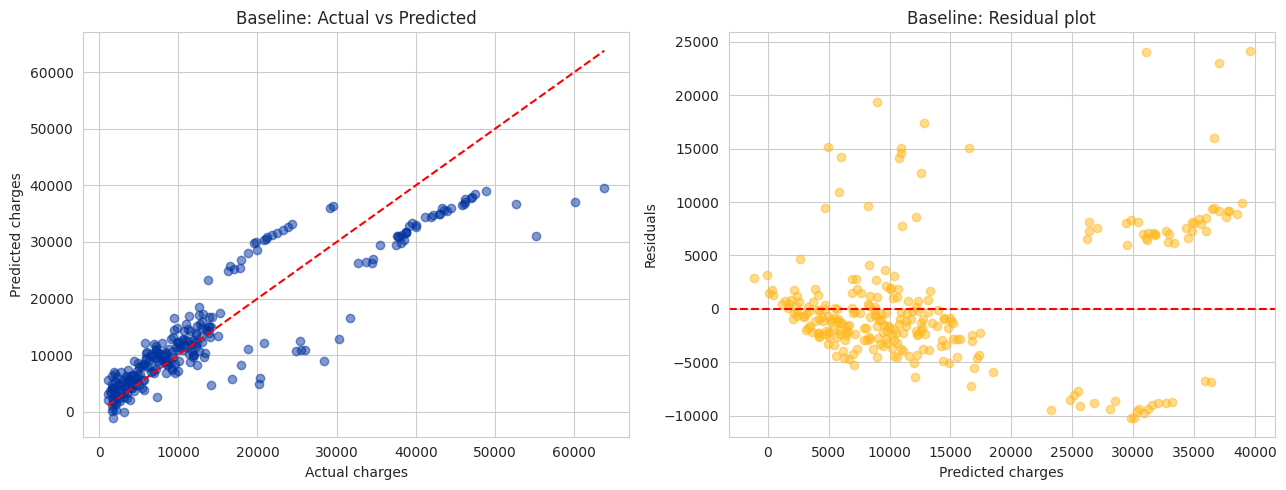

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, pred_baseline, alpha=0.5, color='#0033A0')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual charges')
axes[0].set_ylabel('Predicted charges')
axes[0].set_title('Baseline: Actual vs Predicted')

residuals = y_test - pred_baseline
axes[1].scatter(pred_baseline, residuals, alpha=0.5, color='#FFB81C')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Baseline: Residual plot')
plt.tight_layout()
plt.savefig('figures/05_baseline_diagnostics.png', bbox_inches='tight')
plt.show()


**Shortcomings observed:** the residual plot funnels outward (heteroscedasticity: errors
grow with predicted charge) and shows a distinct second cluster of large positive residuals.
This confirms the pattern spotted in EDA: the model under-predicts high-cost, high-BMI smokers
because it cannot capture the `smoker x bmi` interaction, and the raw right-skewed target
inflates the influence of a few very high-cost observations.

## 9. Retrain with Different Parameters

To address the shortcomings above, the model is retrained with two changes:
1. **Log-transform the target** (`log(charges)`) to reduce skew and stabilise variance.
2. **Add interaction terms** `smoker x bmi` and `smoker x age`, which EDA showed are needed to
   capture the steeper cost curve for smokers.

Predictions are converted back (`exp()`) to the original USD scale before evaluation, so the
improved model is directly comparable to the baseline.

In [15]:
df_enc['smoker_bmi'] = df_enc['smoker'] * df_enc['bmi']
df_enc['smoker_age'] = df_enc['smoker'] * df_enc['age']
df_enc['log_charges'] = np.log(df_enc['charges'])

feature_cols_v2 = ['age', 'bmi', 'children', 'smoker',
                    'region_northwest', 'region_southeast', 'region_southwest',
                    'smoker_bmi', 'smoker_age']
X2 = df_enc[feature_cols_v2]
y2_log = df_enc['log_charges']
y2_actual = df_enc['charges']

X2_train, X2_test, y2log_train, y2log_test, y2_train_actual, y2_test_actual = train_test_split(
    X2, y2_log, y2_actual, test_size=0.2, random_state=42)

improved_model = LinearRegression()
improved_model.fit(X2_train, y2log_train)

pred2_log = improved_model.predict(X2_test)
pred2_actual = np.exp(pred2_log)

results_improved = evaluate(y2_test_actual, pred2_actual, X2_test.shape[1], 'Improved Model (log-target + interactions)')


--- Improved Model (log-target + interactions) ---
R-squared:          0.8311
Adjusted R-squared: 0.8252
RMSE:               $5,571.63
MAE:                $2,911.00



In [16]:
comparison = pd.DataFrame([results_baseline, results_improved]).set_index('label')
comparison


,R2,Adj_R2,RMSE,MAE
label,,,,
Baseline Linear Regression,0.806852,0.801652,5957.529932,4177.653337
Improved Model (log-target + interactions),0.831064,0.825171,5571.630010,2911.002000


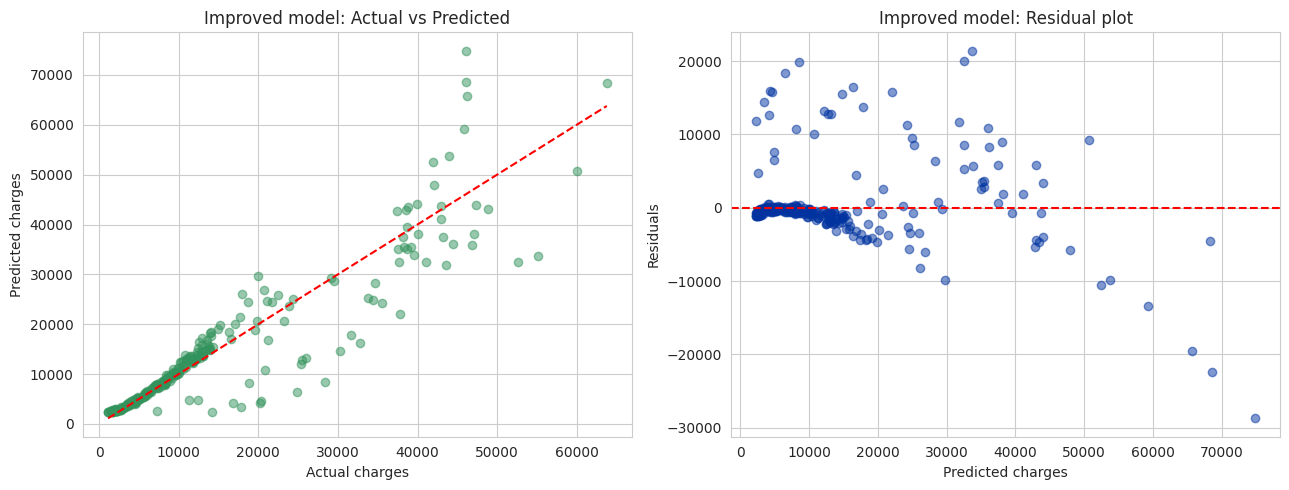

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y2_test_actual, pred2_actual, alpha=0.5, color='#33935C')
axes[0].plot([y2_test_actual.min(), y2_test_actual.max()],
             [y2_test_actual.min(), y2_test_actual.max()], 'r--')
axes[0].set_xlabel('Actual charges')
axes[0].set_ylabel('Predicted charges')
axes[0].set_title('Improved model: Actual vs Predicted')

residuals2 = y2_test_actual - pred2_actual
axes[1].scatter(pred2_actual, residuals2, alpha=0.5, color='#0033A0')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Improved model: Residual plot')
plt.tight_layout()
plt.savefig('figures/06_improved_diagnostics.png', bbox_inches='tight')
plt.show()


**Result:** the improved model raises R-squared and Adjusted R-squared, and, most importantly for the
client, cuts MAE substantially (a much lower average dollar pricing error), because the
`smoker x bmi` and `smoker x age` interaction terms let the model finally capture the steep
cost curve for high-BMI, older smokers rather than under-pricing them. The residual plot for the
improved model is noticeably more evenly scattered around zero, confirming the log-transform
addressed the heteroscedasticity seen in the baseline.

## 10. Conclusion

The improved model (log-transformed target with `smoker x bmi` and `smoker x age` interaction
terms) is recommended as the proof-of-concept sliding-scale pricing model. `smoker` status is by
far the dominant cost driver, followed by its interaction with `bmi` and `age`; `children` and
`region` contribute smaller, statistically defensible adjustments; `sex` was found to have no
predictive value and was dropped.

**Limitations to flag to the client:** this proof of concept is trained on **US** medical cost
data as instructed in the brief. Before deployment on South African clients, the model should
be retrained on local claims data, since absolute charge levels, healthcare cost structures and
regional cost drivers differ materially between the US and South African markets. The modelling
approach, feature selection method and interaction-term insight, however, transfer directly.

Full findings, methodology and business recommendations are presented in the accompanying PDF
report.